## Описание признаков
- SalePrice - the property's sale price in dollars. This is the target variable that you're trying to predict. / цена продажи недвижимости в долларах. Это целевая переменная, которую вы пытаетесь предсказать.
- MSSubClass: The building class / Класс здания
- MSZoning: The general zoning classification / Классы общей зонировки
- LotFrontage: Linear feet of street connected to property / Длина участка, примыкающая к улице в футах
- LotArea: Lot size in square feet / Площадь участка в квадратных футах
- Street: Type of road access / тип подъездной дороги
- Alley: Type of alley access / тип доступа с переулка
- LotShape: General shape of property / форма участка
- LandContour: Flatness of the property / рельеф участка
- Utilities: Type of utilities available / доступные коммуникации
- LotConfig: Lot configuration / конфигурация участка
- LandSlope: Slope of property / уклон участка
- Neighborhood: Physical locations within Ames city limits / Физическое расположение в пределах городской черты
- Condition1: Proximity to main road or railroad / близость к дороге/железной дороге
- Condition2: Proximity to main road or railroad (if a second is present) / близость к дороге/железной дороге, если есть вторая
- BldgType: Type of dwelling / Тип жилища
- HouseStyle: Style of dwelling / архитектурный стиль
- OverallQual: Overall material and finish quality / общее качество материалов и отделки
- OverallCond: Overall condition rating / общее состояние дома
- YearBuilt: Original construction date / год постройки
- YearRemodAdd: Remodel date / год реконструкции
- RoofStyle: Type of roof / Тип крыши
- RoofMatl: Roof material / материал крыши
- Exterior1st: Exterior covering on house / основной материал фасада
- Exterior2nd: Exterior covering on house (if more than one material) / дополнительный материал фасада
- MasVnrType: Masonry veneer type / тип облицовки камнем
- MasVnrArea: Masonry veneer area in square feet / площадь каменной облицовки
- ExterQual: Exterior material quality / качество внешних материалов
- ExterCond: Present condition of the material on the exterior / состояние фасада
- Foundation: Type of foundation / тип фундамента
- BsmtQual: Height of the basement / высота/качество подвала
- BsmtCond: General condition of the basement / состояние подвала
- BsmtExposure: Walkout or garden level basement walls / выход подвала наружу
- BsmtFinType1: Quality of basement finished area /  качество отделки подвала 1 
- BsmtFinSF1: Type 1 finished square feet / площадь отделанного подвала 1 
- BsmtFinType2: Quality of second finished area (if present) / качество отделки подвала 2
- BsmtFinSF2: Type 2 finished square feet / площадь отделанного подвала 2
- BsmtUnfSF: Unfinished square feet of basement area / неотделанная площадь подвала
- TotalBsmtSF: Total square feet of basement area / общая площадь подвала
- Heating: Type of heating / Тип отопления
- HeatingQC: Heating quality and condition / качество и состояние отопления
- CentralAir: Central air conditioning / центральный кондиционер
- Electrical: Electrical system / электрическая система
- 1stFlrSF: First Floor square feet / площадь первого этажа
- 2ndFlrSF: Second floor square feet / площадь второго этажа
- LowQualFinSF: Low quality finished square feet (all floors) / низкокачественная отделка
- GrLivArea: Above grade (ground) living area square feet / жилая площадь над землей
- BsmtFullBath: Basement full bathrooms / ванные комнаты в подвале
- BsmtHalfBath: Basement half bathrooms / туалеты в подвале
- FullBath: Full bathrooms above grade / ванные комнаты в доме
- HalfBath: Half baths above grade / туалеты без ванны
- Bedroom: Number of bedrooms above basement level / количество спален
- Kitchen: Number of kitchens / количество кухонь
- KitchenQual: Kitchen quality / качество кухни
- TotRmsAbvGrd: Total rooms above grade (does not include bathrooms) / комнаты (без санузлов)
- Functional: Home functionality rating / функциональность планировки
- Fireplaces: Number of fireplaces / количество каминов
- FireplaceQu: Fireplace quality / качество камина
- GarageType: Garage location / расположение гаража
- GarageYrBlt: Year garage was built / год постройки гаража
- GarageFinish: Interior finish of the garage / отделка гаража
- GarageCars: Size of garage in car capacity / вместимость (машины)
- GarageArea: Size of garage in square feet / площадь гаража
- GarageQual: Garage quality / качество гаража
- GarageCond: Garage condition / состояние гаража
- PavedDrive: Paved driveway / асфальтированный подъезд
- WoodDeckSF: Wood deck area in square feet / площадь деревянной террасы
- OpenPorchSF: Open porch area in square feet / открытая веранда
- EnclosedPorch: Enclosed porch area in square feet / закрытая веранда
- 3SsnPorch: Three season porch area in square feet / веранда на 3 сезона
- ScreenPorch: Screen porch area in square feet / веранда с сеткой
- PoolArea: Pool area in square feet / площадь бассейна
- PoolQC: Pool quality / качество бассейна
- Fence: Fence quality / качество забора
- MiscFeature: Miscellaneous feature not covered in other categories / прочие особенности
- MiscVal: $Value of miscellaneous feature / стоимость этих особенностей
- MoSold: Month Sold / месяц продажи
- YrSold: Year Sold / Год продажи
- SaleType: Type of sale / тип сделки
Обычная продажа, наследство, аукцион и т.п.
- SaleCondition: Condition of sale / условия сделки
Срочная, нормальная, проблемная.

In [182]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from scipy.stats import chi2_contingency

from catboost import CatBoostRegressor, Pool
from sklearn.model_selection import train_test_split
from sklearn.metrics import root_mean_squared_error
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

import optuna

import json
import os

from sklearn.linear_model import LassoCV, RidgeCV
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.ensemble import StackingRegressor

from sklearn.ensemble import StackingRegressor
from sklearn.linear_model import Ridge

# 1. EDA

In [183]:
train_data = pd.read_csv("data/train.csv")
test_data = pd.read_csv("data/test.csv")

test_id = test_data['Id']
train_data.drop('Id', axis=1, inplace=True)
test_data.drop('Id', axis=1, inplace=True)

In [184]:
train_data.head() 

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [185]:
test_data.head()

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,Inside,...,120,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal
1,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,Corner,...,0,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal
2,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,Inside,...,0,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal
3,60,RL,78.0,9978,Pave,NaN,IR1,Lvl,AllPub,Inside,...,0,0,NaN,NaN,NaN,0,6,2010,WD,Normal
4,120,RL,43.0,5005,Pave,NaN,IR1,HLS,AllPub,Inside,...,144,0,NaN,NaN,NaN,0,1,2010,WD,Normal


In [186]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 80 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   MSSubClass     1460 non-null   int64  
 1   MSZoning       1460 non-null   object 
 2   LotFrontage    1201 non-null   float64
 3   LotArea        1460 non-null   int64  
 4   Street         1460 non-null   object 
 5   Alley          91 non-null     object 
 6   LotShape       1460 non-null   object 
 7   LandContour    1460 non-null   object 
 8   Utilities      1460 non-null   object 
 9   LotConfig      1460 non-null   object 
 10  LandSlope      1460 non-null   object 
 11  Neighborhood   1460 non-null   object 
 12  Condition1     1460 non-null   object 
 13  Condition2     1460 non-null   object 
 14  BldgType       1460 non-null   object 
 15  HouseStyle     1460 non-null   object 
 16  OverallQual    1460 non-null   int64  
 17  OverallCond    1460 non-null   int64  
 18  YearBuil

Наблюдаем достаточно большое кол-во признаков. Попробуем для начала выделить и разобрать самые важные.
Начнем с целевой переменной. Посмотрим на её распределение.

<Axes: xlabel='SalePrice', ylabel='Count'>

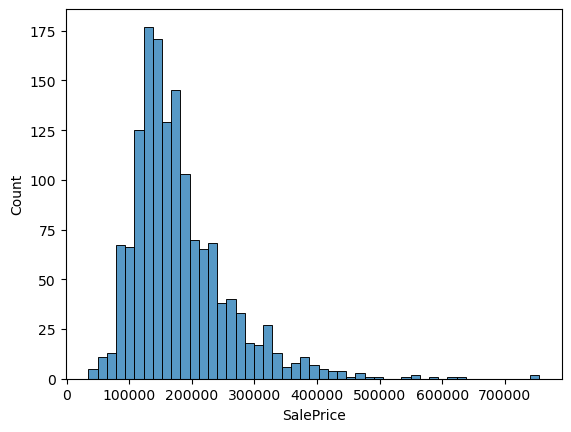

In [187]:
sns.histplot(train_data["SalePrice"])

Видим распределение с правым хвостом. Это значит, что на рынке представлено больше дешевого жилья и редкие представители очень дорогово.  

## Корреляция

Отберем самые важные на первый взгляд признаки.


На мой взгляд важными могут быть следующие переменные: MSSubClass (Класс здания), LotArea (Площадь участка), Neighborhood (расположение в пределах городской черты), BldgType (Тип жилища), OverallQual (общее качество материалов и отделки), OverallCond (общее состояние дома), YearBuilt (год постройки), ExterCond (состояние фасада), Foundation (тип фундамента), TotalBsmtSF (общая площадь подвала), 1stFlrSF (площадь первого этажа), 2ndFlrSF (площадь второго этажа), GrLivArea (жилая площадь над землей), Bedroom (количество спален), TotRmsAbvGrd (комнаты), Functional (функциональность планировки), YrSold (Год продажи), SaleType (тип сделки), SaleCondition (условия сделки).  
Но давайте лучше проверим все числовые признаки на коллинеарность.

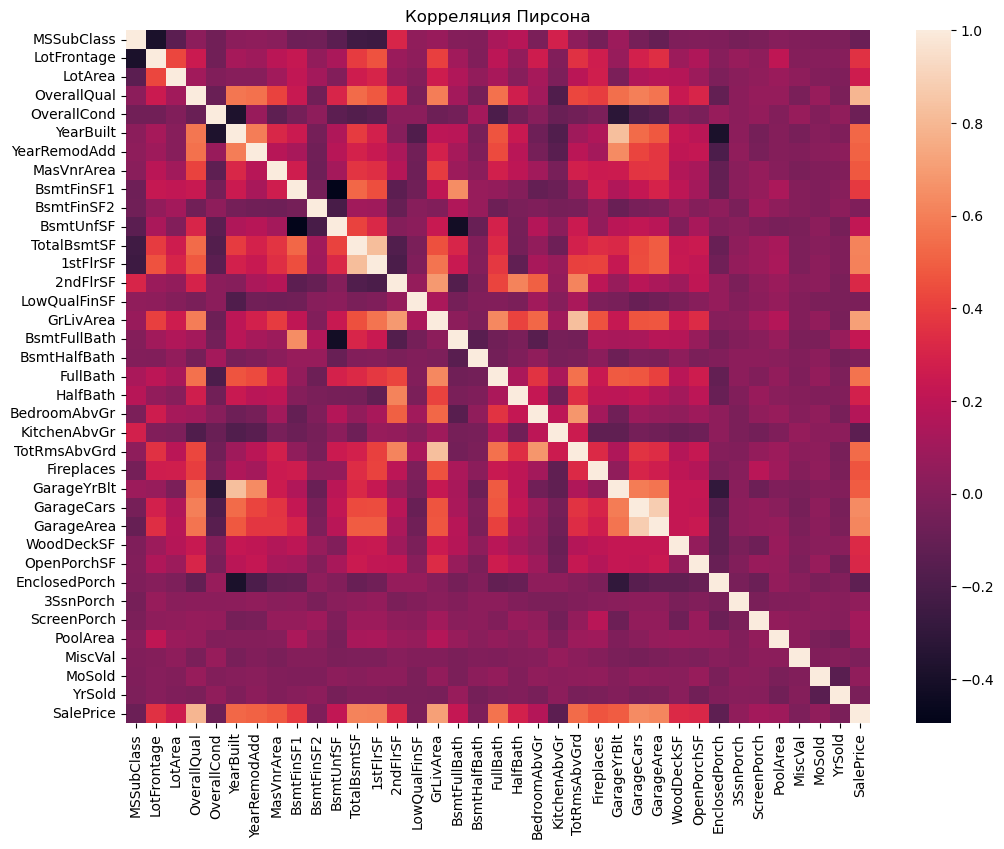

In [188]:
train_data_digits = train_data.select_dtypes(include=['number'])
corrmat = train_data_digits.corr()
f, ax = plt.subplots(figsize=(12, 9))
plt.title("Корреляция Пирсона")
sns.heatmap(corrmat);

Для удобства отобразим признаки с корреляцией выше 0.5 с целевой переменной SalePrice.

<Axes: >

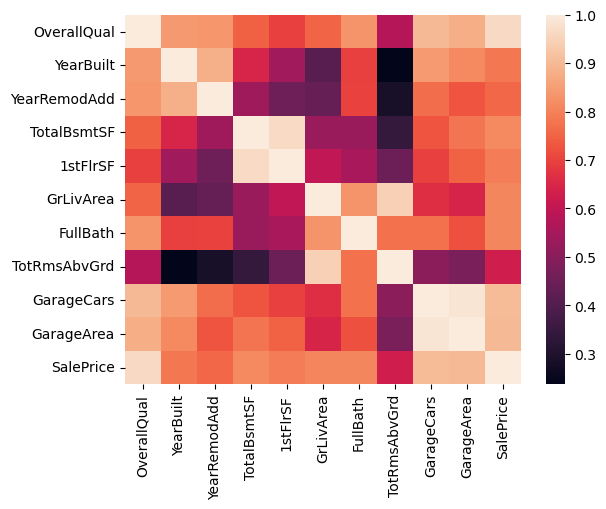

In [189]:
cols = corrmat[corrmat["SalePrice"] > 0.5]["SalePrice"].index
cm = np.corrcoef(corrmat[cols].values.T)
sns.heatmap(cm, yticklabels=cols.values, xticklabels=cols.values)

In [190]:
cols.values

array(['OverallQual', 'YearBuilt', 'YearRemodAdd', 'TotalBsmtSF',
       '1stFlrSF', 'GrLivArea', 'FullBath', 'TotRmsAbvGrd', 'GarageCars',
       'GarageArea', 'SalePrice'], dtype=object)

Видим что корреляция имеется у:  
'OverallQual', 'YearBuilt', 'YearRemodAdd', 'TotalBsmtSF', 
       '1stFlrSF', 'GrLivArea', 'FullBath', 'TotRmsAbvGrd', 'GarageCars',
       'GarageArea', 'SalePrice'.  
Также сразу видно, что есть сильная корреляция между собой у GarageCars и GarageArea, потому что они несут похожий смысл. Удалим GarageArea, т.к. GarageCars коррелирует чуть сильнее с целевым признаком.
TotalBsmtSF и 1stFlrSF. Площадь первого этажа коррелирует с площадью подвала. Будто бы это не всегда правда, но оставим TotalBsmtSF.  
'TotRmsAbvGrd' и  'GrLivArea' Тут по смыслу понятно, что жилая площадь и кол-во комнат говорят о похожем. Хотя при этом корреляция с SalePrice сильно отличается. Оставим GrLivArea.

Учитывая ненормальность распределения целевой переменной, сразу посмотрим еще и корреляцию spearman.

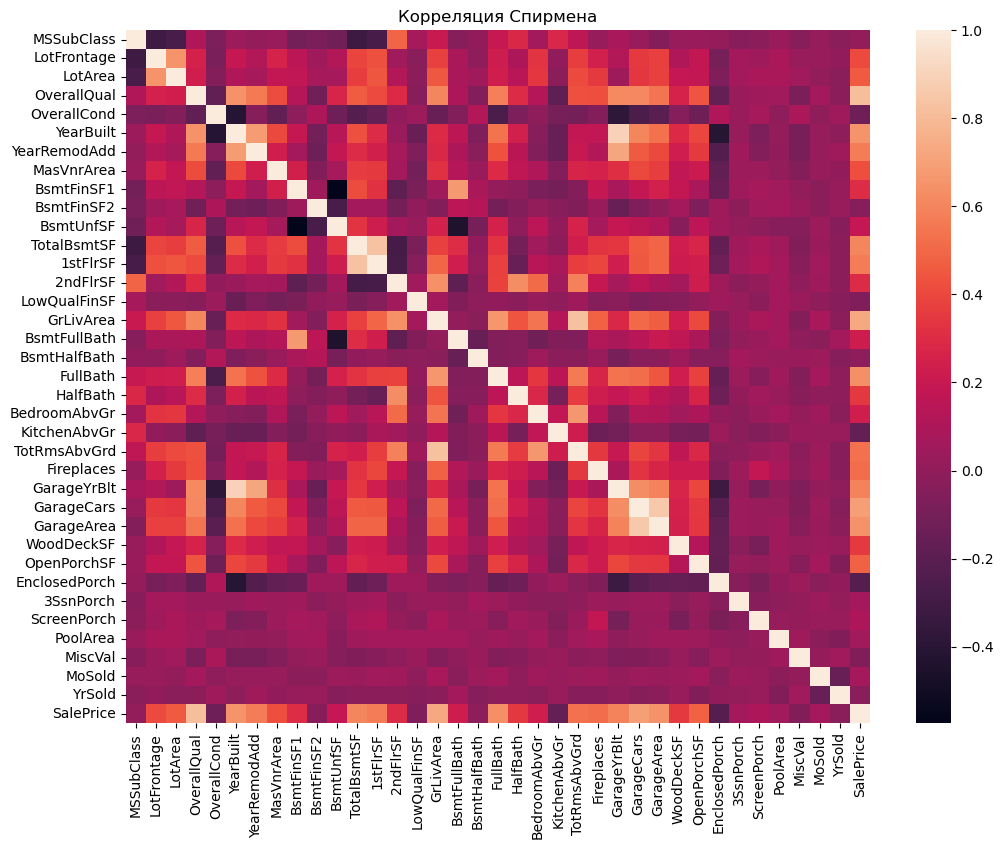

In [191]:
train_data_digits = train_data.select_dtypes(include=['number'])
corrmat_spearman = train_data_digits.corr(method='spearman')
f, ax = plt.subplots(figsize=(12, 9))
plt.title("Корреляция Спирмена")
sns.heatmap(corrmat_spearman);

<Axes: >

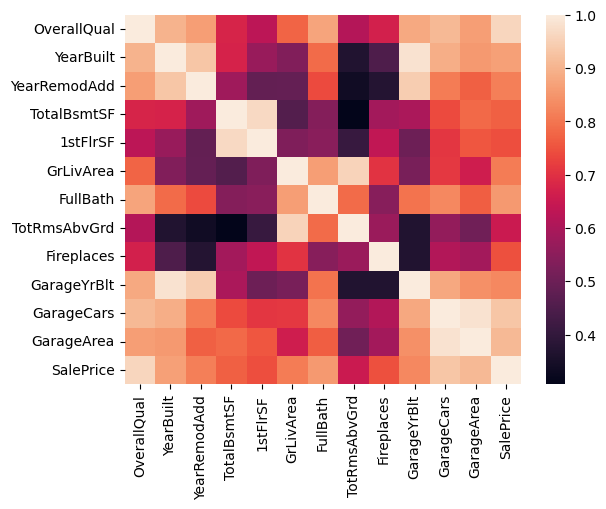

In [192]:
cols = corrmat_spearman[corrmat_spearman["SalePrice"] > 0.5]["SalePrice"].index
cm = np.corrcoef(corrmat_spearman[cols].values.T)
sns.heatmap(cm, yticklabels=cols.values, xticklabels=cols.values)

In [193]:
pearson = corrmat[corrmat["SalePrice"] > 0.5]["SalePrice"]
spearman = corrmat_spearman[corrmat["SalePrice"] > 0.5]["SalePrice"]

diff = (spearman - pearson).sort_values(ascending=False)
print("Признаки, где Спирмен 'видит' связь лучше Пирсона (кандидаты на log):")
print(diff)

Признаки, где Спирмен 'видит' связь лучше Пирсона (кандидаты на log):
YearBuilt       0.129784
FullBath        0.075293
YearRemodAdd    0.064058
GarageCars      0.050302
GarageArea      0.025947
GrLivArea       0.022685
OverallQual     0.018847
SalePrice       0.000000
TotRmsAbvGrd   -0.001137
TotalBsmtSF    -0.010855
1stFlrSF       -0.030444
Name: SalePrice, dtype: float64


Видим, что год постройки имеет нелинейную зависимость от цены, а значит может быть полезно применить к цене логарифм.  
С другой стороны мы видим, что между TotRmsAbvGrd зависимость скорее прямая.



Посмотрим графики зависимости отобранных числовых признаков с нашей целевой переменной SalePrice

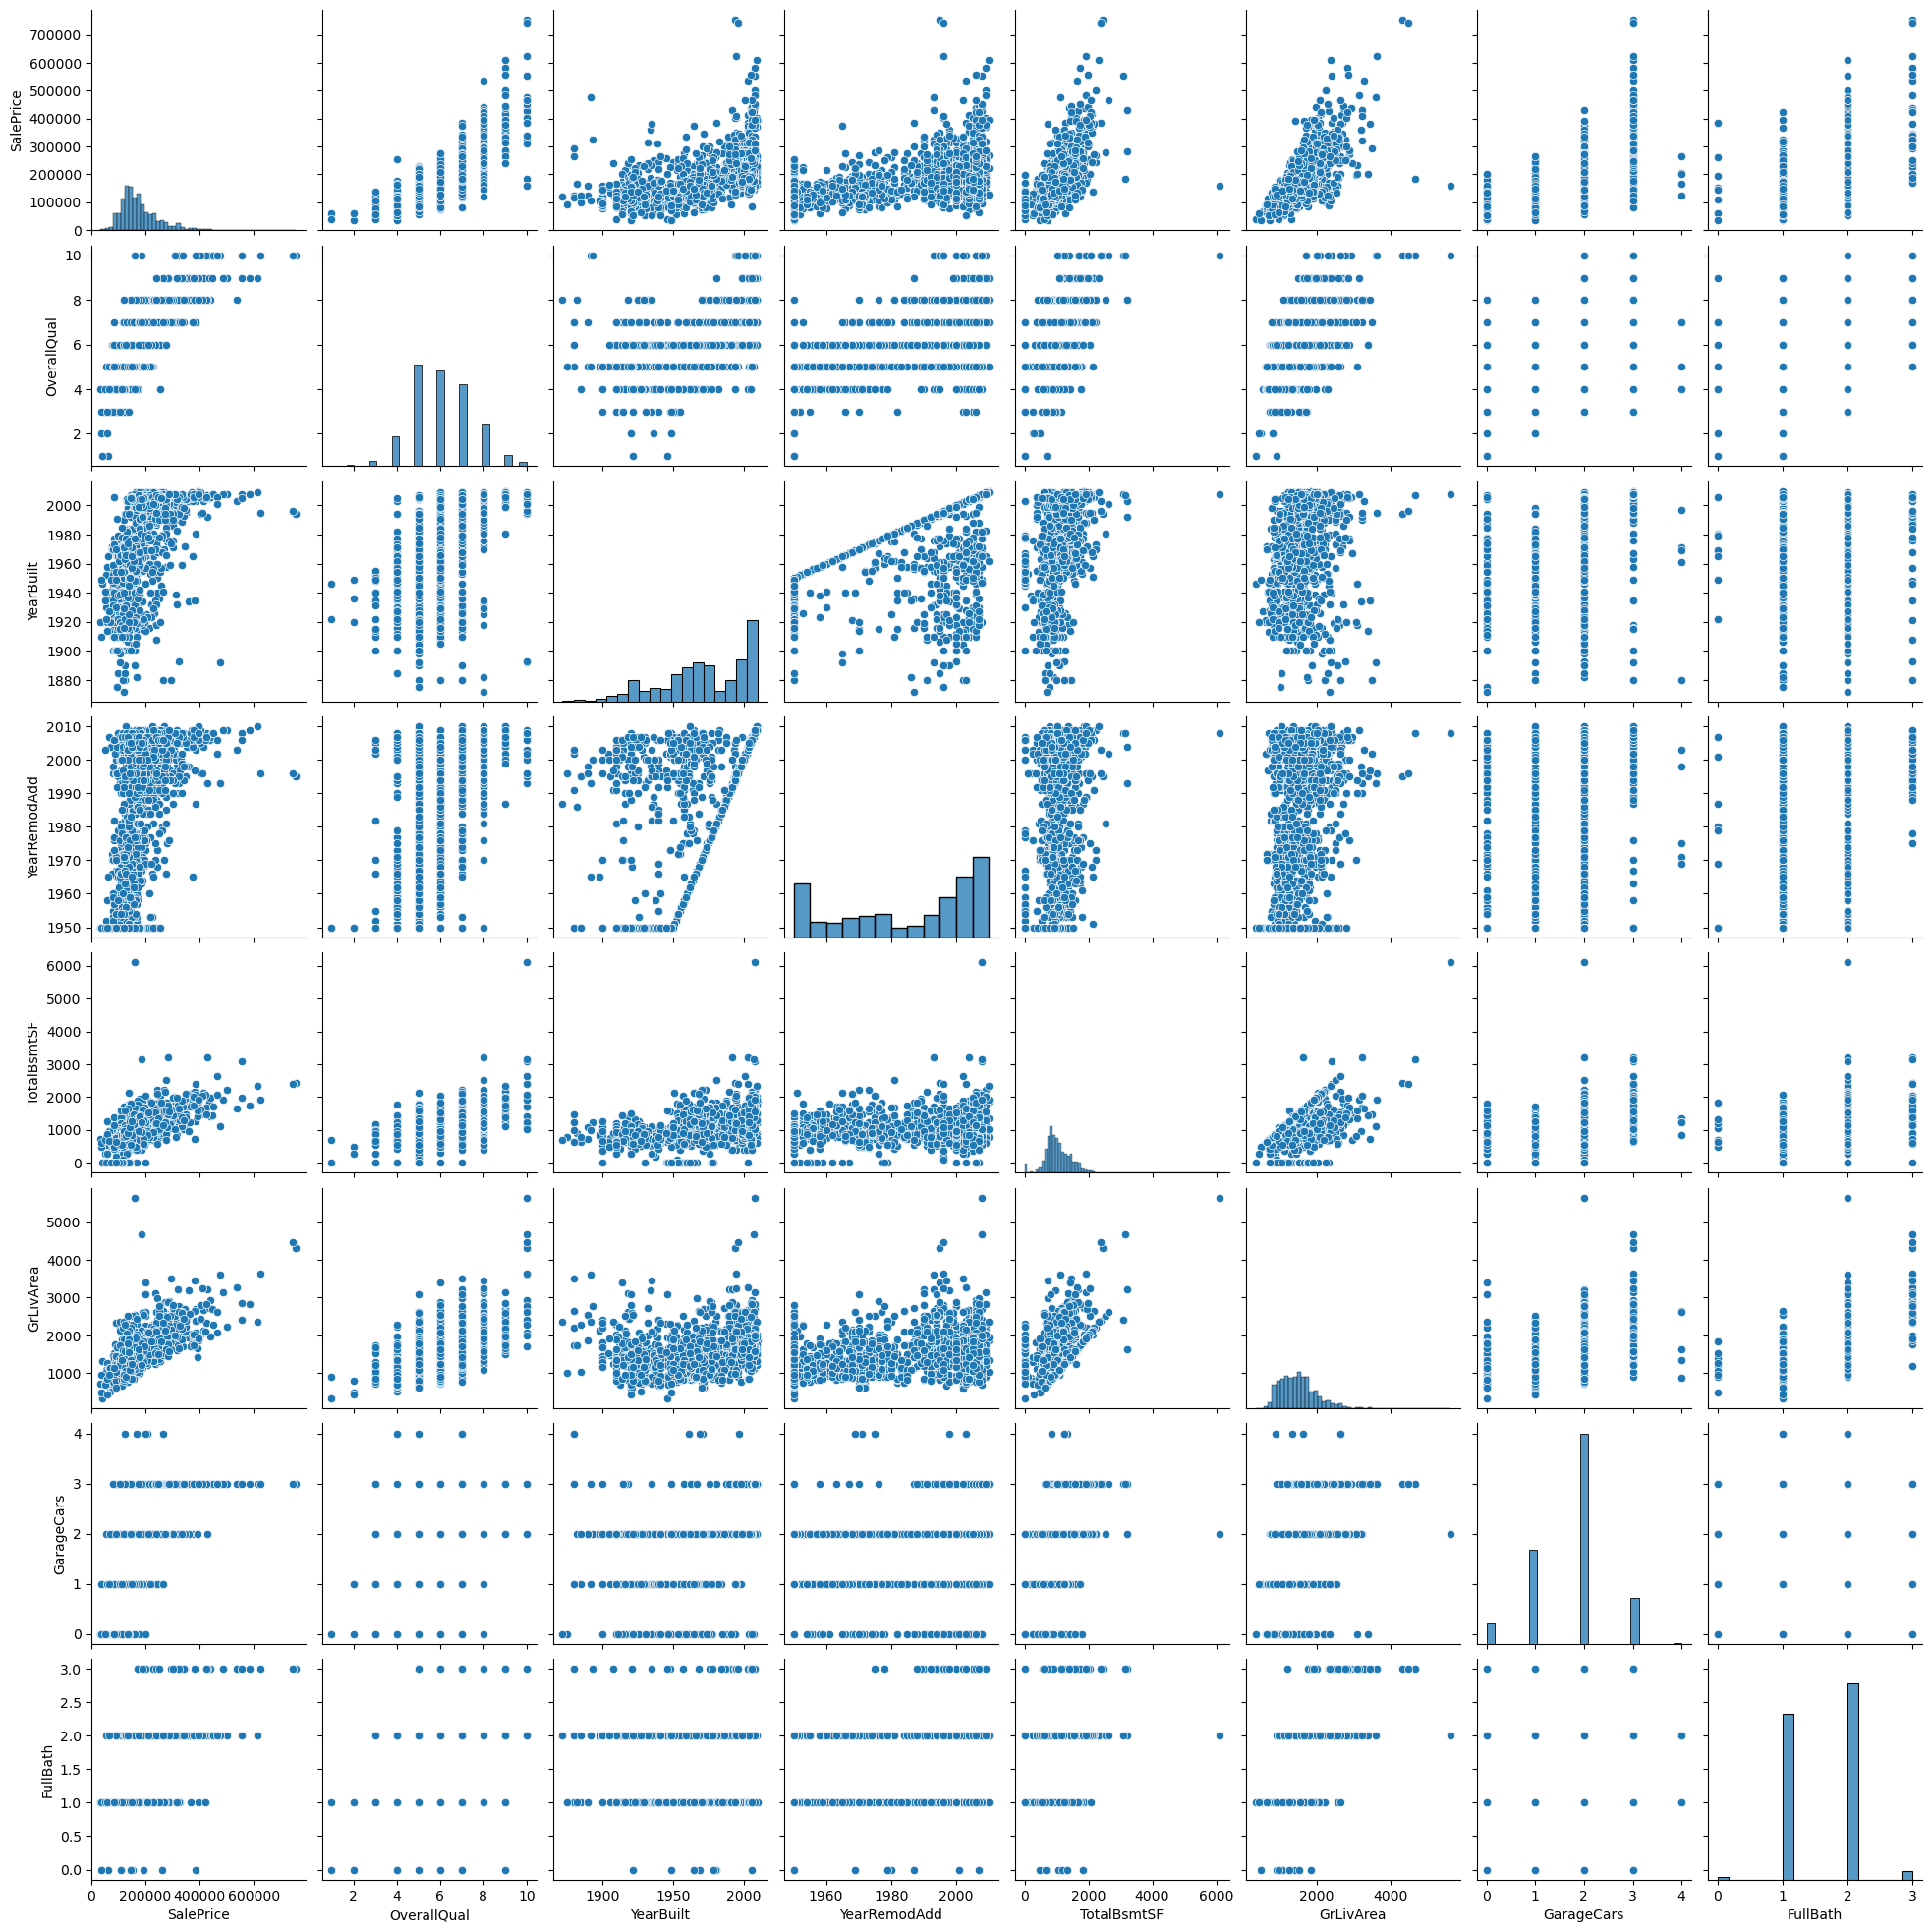

In [194]:
cols = ['SalePrice', 'OverallQual', 'YearBuilt', 'YearRemodAdd',  'TotalBsmtSF',  'GrLivArea', 'GarageCars', 'FullBath']
sns.pairplot(train_data_digits[cols], height = 2.5)

Видим логичные отбивки в пересечениях YearRemodAdd и YearBuilt. Нельзя сделать реновацию раньше постройки.  
Видим отбивку в пересечении TotalBsmtSF и GrLivArea. Вероятно связано это с тем, что редко подвал бывает больше площади дома.
На пересечении YearBuilt и SalePrice видно, что последнее время цена стала расти быстрее, чем раньше, что подтверждает нелинейность.

Найдем теперь самые значимые признаки из категориальных.

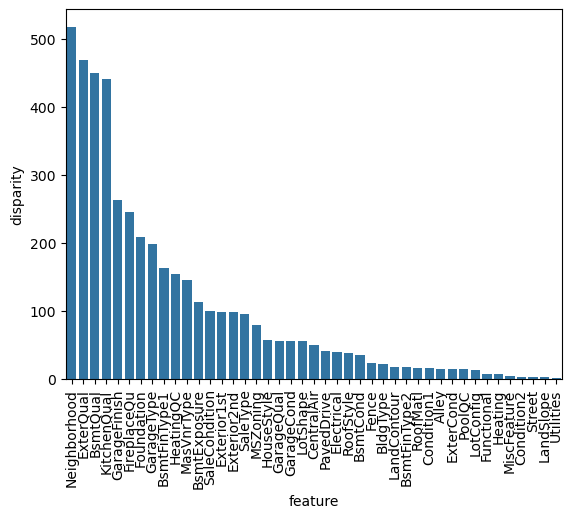

In [195]:
def anova(frame, categorical_columns):
    anv = pd.DataFrame()
    anv['feature'] = categorical_columns
    pvals = []
    for c in categorical_columns:
        samples = []
        for cls in frame[c].unique():
            s = frame[frame[c] == cls]['SalePrice'].values
            samples.append(s)
        pval = stats.f_oneway(*samples)[1]
        pvals.append(pval)
    anv['pval'] = pvals
    return anv.sort_values('pval')

qualitative = train_data.select_dtypes(include=['object']).columns
train_data[qualitative] = train_data[qualitative].fillna('MISSING')
test_data[qualitative] = test_data[qualitative].fillna('MISSING')

a = anova(train_data, qualitative)
a['disparity'] = np.log(1./a['pval'].values)
sns.barplot(data=a, x='feature', y='disparity')
x=plt.xticks(rotation=90)

Проверим то же самое, но уже с логорифмом

In [196]:
train_data['SalePrice'] = np.log1p(train_data['SalePrice'])

<Axes: xlabel='SalePrice', ylabel='Count'>

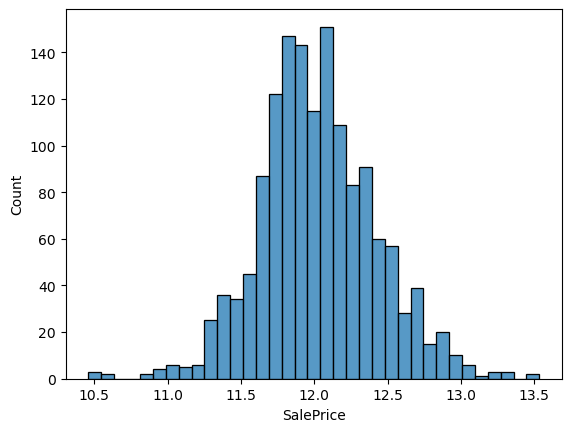

In [197]:
sns.histplot(train_data["SalePrice"])

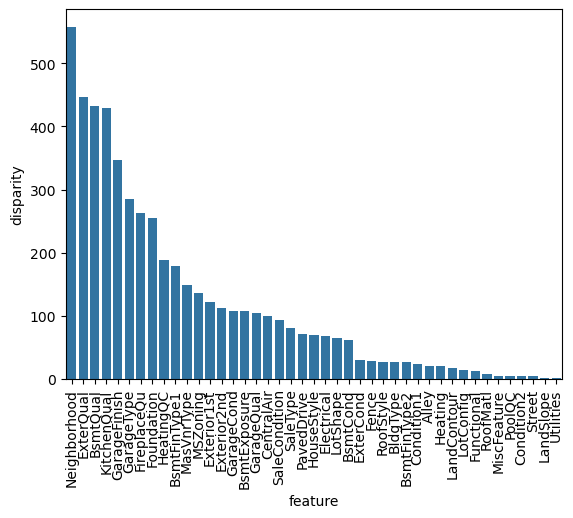

In [198]:
def anova(frame, categorical_columns):
    anv = pd.DataFrame()
    anv['feature'] = categorical_columns
    pvals = []
    for c in categorical_columns:
        samples = []
        for cls in frame[c].unique():
            s = frame[frame[c] == cls]['SalePrice'].values
            samples.append(s)
        pval = stats.f_oneway(*samples)[1]
        pvals.append(pval)
    anv['pval'] = pvals
    return anv.sort_values('pval')

qualitative = train_data.select_dtypes(include=['object']).columns



a = anova(train_data, qualitative)
a['disparity'] = np.log(1./a['pval'].values)
sns.barplot(data=a, x='feature', y='disparity')
x=plt.xticks(rotation=90)

In [199]:
a.head(10)

,feature,pval,disparity
8,Neighborhood,4.041201e-243,558.131636
18,ExterQual,6.930372e-195,447.068180
21,BsmtQual,2.029970e-188,432.177977
30,KitchenQual,4.438817e-187,429.093024
34,GarageFinish,4.058066e-151,346.289642
33,GarageType,8.430356e-125,285.691298
32,FireplaceQu,6.961918e-115,262.856831
20,Foundation,1.350599e-111,255.286397
27,HeatingQC,1.614912e-82,188.332697
24,BsmtFinType1,4.320809e-78,178.138195


Из влияющих на целевую переменную признаков можно выделить: Neighborhood (Физическое расположение), ExterQual (качество внешних материалов), BsmtQual (качество подвала), KitchenQual (Качество кухни), GarageFinish (отделка гаража), GarageType (расположение гаража), FireplaceQu (качество камина), HeatingQC (состояние отопления), BsmtFinType1 (качество отделки подвала).
Проверим связаны ли эти признаки. Предположительно GarageFinish и GarageType могут показывать одно и то же.

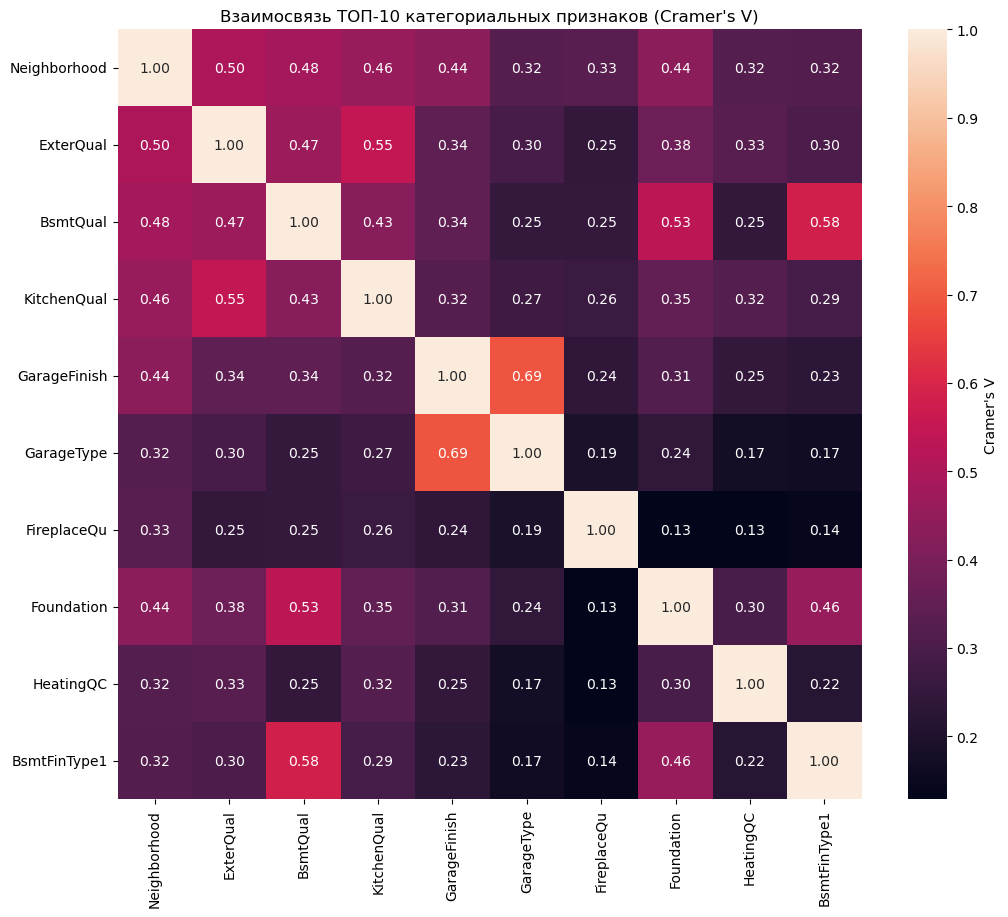

In [200]:
def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    # Если в признаке всего одна категория, возвращаем 0
    if min(k - 1, r - 1) == 0:
        return 0
    return np.sqrt(phi2 / min(k - 1, r - 1))

top_n = 10
top_features = a.sort_values('disparity', ascending=False).head(top_n)['feature'].tolist()


v_matrix = pd.DataFrame(index=top_features, columns=top_features, dtype=float)

for f1 in top_features:
    for f2 in top_features:
        v_matrix.loc[f1, f2] = cramers_v(train_data[f1], train_data[f2])

plt.figure(figsize=(12, 10))
sns.heatmap(v_matrix, annot=True, fmt='.2f', cbar_kws={'label': "Cramer's V"})
plt.title(f"Взаимосвязь ТОП-{top_n} категориальных признаков (Cramer's V)")
plt.show()

Как и ожидалось, GarageFinish и GarageType оказались связаны. Можно будет попробовать убрать один из признаков или объединить их в один новый признак.

# 2. Обработка пропущенных значений

Склеим трейн и тест сеты

In [201]:
train_data.shape

(1460, 80)

In [202]:
test_data.shape

(1459, 79)

In [203]:
y = train_data['SalePrice']
all_data = pd.concat([train_data.drop('SalePrice', axis=1), test_data], ignore_index=True)

In [204]:
all_data.shape

(2919, 79)

In [205]:
null_count = all_data.isnull().sum().sort_values(ascending =False)
percent = (all_data.isnull().sum() / all_data.isnull().count()).sort_values(ascending=False)
pd.concat([null_count, percent], axis=1, keys=['null_count', 'Percent']).head(20)

,null_count,Percent
LotFrontage,486,0.166495
GarageYrBlt,159,0.054471
MasVnrArea,23,0.007879
BsmtFullBath,2,0.000685
BsmtHalfBath,2,0.000685
BsmtFinSF2,1,0.000343
TotalBsmtSF,1,0.000343
BsmtUnfSF,1,0.000343
BsmtFinSF1,1,0.000343
GarageCars,1,0.000343


In [206]:
missing_count = (all_data == 'MISSING').sum().sort_values(ascending=False)
percent = (missing_count / len(all_data)).sort_values(ascending=False)
pd.concat([missing_count, percent], axis=1, keys=['missing_count', 'Percent']).head(20)

,missing_count,Percent
PoolQC,2909,0.996574
MiscFeature,2814,0.964029
Alley,2721,0.932169
Fence,2348,0.804385
MasVnrType,1766,0.605002
FireplaceQu,1420,0.486468
GarageQual,159,0.054471
GarageCond,159,0.054471
GarageFinish,159,0.054471
GarageType,157,0.053786


PoolQC, MiscFeature, Alley, Fence, MasVnrType, FireplaceQu - содержат большое кол-во пропусков от 47% и выше.
PoolQC (качество бассейна), MiscFeature(прочие особенности), Alley (тип доступа с переулка), Fence (забор), Качество камина (FireplaceQu) - Вероятно, не несут большого значения для определения стоимости жилища. Поэтому мы их использовать не будем.  
MasVnrType (тип облицовки камнем) с учетом кол-ва пропусков тоже вряд ли будет нам полезен. Тем более что у нас есть более коррелирующий признак общего качества, который вероятно подразумевает и оценку облицовки. 

mean: 69.30579531442663
median: 68.0


<Axes: >

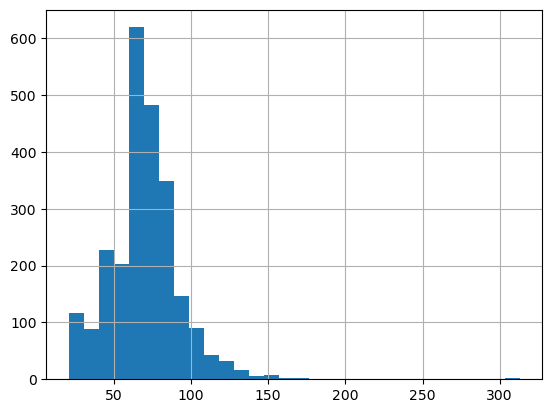

In [207]:
LotFrontage_mean = all_data['LotFrontage'].mean()
LotFrontage_median = all_data['LotFrontage'].median()
print(f"mean: {LotFrontage_mean}")
print(f"median: {LotFrontage_median}")
all_data['LotFrontage'].hist(bins=30)

Рассматривая гистограмму для LotFrontage можно увидеть, что медиана и среднее у нас находится примерно в одной точке. И можно попробовать пропуски заменить медианой. У нас и так острый пик. В теории распределение не должно сильно пострадать.

In [208]:
all_data['LotFrontage'] = all_data['LotFrontage'].fillna(all_data['LotFrontage'].median())

In [209]:
numeric_cols = all_data.select_dtypes(include=['number']).columns
all_data[numeric_cols] = all_data[numeric_cols].fillna(0)

Большинство категориальных прихнаков оставим MISSING. 
В Electrical отсутствует одно значение. Посмотрим сколько пропусков в этой строке. Если много, то удалим строку. Если нет, заполним модой.

In [210]:
rows = all_data.loc[all_data['Electrical']=='MISSING']
cols_with_nan = rows.columns[rows[rows=='MISSING'].any()]
rows[cols_with_nan]

,Alley,MasVnrType,Electrical,FireplaceQu,PoolQC,Fence,MiscFeature
1379,MISSING,MISSING,MISSING,MISSING,MISSING,MISSING,MISSING


Учитывая, что пропуски в основном в колонках, которые мы не будем использовать, то заполню её модой.

In [211]:
all_data[all_data['Electrical']=='MISSING']['Electrical'] = all_data['Electrical'].mode()[0]

C:\Users\Shurik\AppData\Local\Temp\ipykernel_22332\562275760.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  all_data[all_data['Electrical']=='MISSING']['Electrical'] = all_data['Electrical'].mode()[0]


# 3. Feature Engineering

Объединим GarageFinish и GarageType в один признак


In [212]:
all_data["GarageFinish"].value_counts()

GarageFinish
Unf        1230
RFn         811
Fin         719
MISSING     159
Name: count, dtype: int64

In [213]:
all_data["GarageType"].value_counts()

GarageType
Attchd     1723
Detchd      779
BuiltIn     186
MISSING     157
Basment      36
2Types       23
CarPort      15
Name: count, dtype: int64

In [214]:
all_data['Garage_Score'] = all_data['GarageType'].astype(str) + "_" + all_data['GarageFinish'].astype(str)
print(f"Уникальных комбинаций до объединения: {all_data['GarageType'].nunique()} и {all_data['GarageFinish'].nunique()}")
print(f"Уникальных комбинаций в новом признаке: {all_data['Garage_Score'].nunique()}")

Уникальных комбинаций до объединения: 7 и 4
Уникальных комбинаций в новом признаке: 18


In [215]:
y

0       12.247699
1       12.109016
2       12.317171
3       11.849405
4       12.429220
          ...    
1455    12.072547
1456    12.254868
1457    12.493133
1458    11.864469
1459    11.901590
Name: SalePrice, Length: 1460, dtype: float64

        feature   disparity
2  Garage_Score  374.336432
1  GarageFinish  346.289642
0    GarageType  285.691298


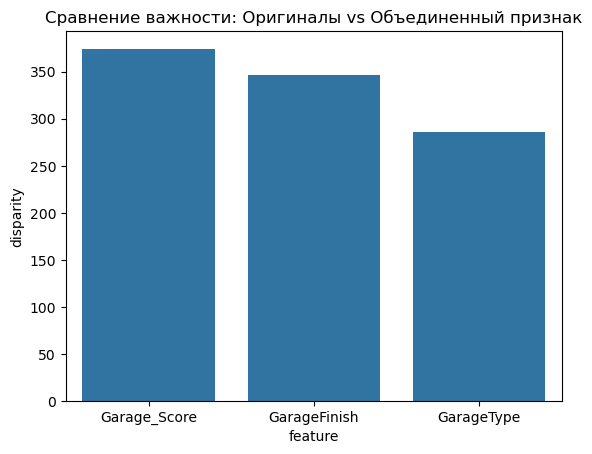

In [216]:
# Список для теста
test_features = ['GarageType', 'GarageFinish', 'Garage_Score']

# Вызываем вашу функцию ANOVA
# (Убедитесь, что таргет SalePrice в train_data на месте)
temp_train_data = all_data.iloc[:1460].copy()
temp_train_data["SalePrice"] = y.values
a_check = anova(temp_train_data, test_features)

# Считаем disparity
a_check['disparity'] = np.log(1./a_check['pval'].values)

print(a_check[['feature', 'disparity']])

# Визуализация
sns.barplot(data=a_check, x='feature', y='disparity')
plt.title("Сравнение важности: Оригиналы vs Объединенный признак")
plt.show()

In [217]:
counts = all_data['Garage_Score'].value_counts()
counts

Garage_Score
Detchd_Unf         719
Attchd_RFn         716
Attchd_Fin         554
Attchd_Unf         453
MISSING_MISSING    157
BuiltIn_Fin        127
BuiltIn_RFn         48
Detchd_RFn          34
Detchd_Fin          24
Basment_Unf         17
2Types_Unf          15
CarPort_Unf         15
BuiltIn_Unf         11
Basment_Fin         11
Basment_RFn          8
2Types_RFn           5
2Types_Fin           3
Detchd_MISSING       2
Name: count, dtype: int64

In [218]:
threshold = 20
rare_categories = counts[counts < threshold].index
rare_categories

Index(['Basment_Unf', '2Types_Unf', 'CarPort_Unf', 'BuiltIn_Unf',
       'Basment_Fin', 'Basment_RFn', '2Types_RFn', '2Types_Fin',
       'Detchd_MISSING'],
      dtype='object', name='Garage_Score')

In [219]:
all_data['Garage_Score'] = all_data['Garage_Score'].replace(rare_categories, 'Other')

In [220]:
all_data['Garage_Score'].value_counts()

Garage_Score
Detchd_Unf         719
Attchd_RFn         716
Attchd_Fin         554
Attchd_Unf         453
MISSING_MISSING    157
BuiltIn_Fin        127
Other               87
BuiltIn_RFn         48
Detchd_RFn          34
Detchd_Fin          24
Name: count, dtype: int64

        feature   disparity
2  Garage_Score  385.566551
1  GarageFinish  346.289642
0    GarageType  285.691298


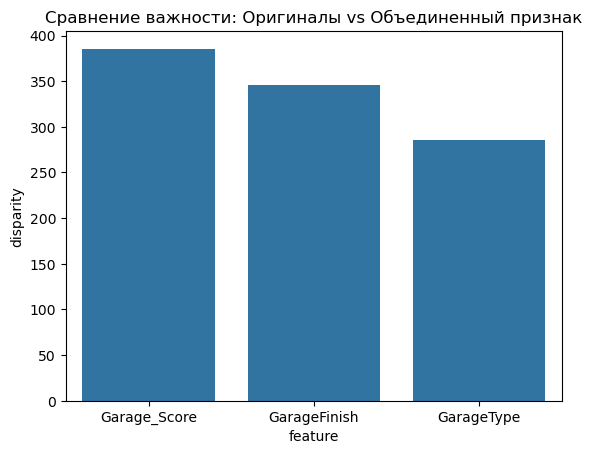

In [221]:
test_features = ['GarageType', 'GarageFinish', 'Garage_Score']

temp_train_data = all_data.iloc[:1460].copy()
temp_train_data["SalePrice"] = y.values

a_check = anova(temp_train_data, test_features)

a_check['disparity'] = np.log(1./a_check['pval'].values)

print(a_check[['feature', 'disparity']])


sns.barplot(data=a_check, x='feature', y='disparity')
plt.title("Сравнение важности: Оригиналы vs Объединенный признак")
plt.show()

Соберем все отобранные признаки вместе

In [222]:
numeric = corrmat[corrmat["SalePrice"] > 0.5]["SalePrice"].index.tolist()[:-1]
numeric

['OverallQual',
 'YearBuilt',
 'YearRemodAdd',
 'TotalBsmtSF',
 '1stFlrSF',
 'GrLivArea',
 'FullBath',
 'TotRmsAbvGrd',
 'GarageCars',
 'GarageArea']

In [223]:
categicorical = a.sort_values('disparity', ascending=False).head(10)['feature'].tolist()
categicorical.append('Garage_Score')
categicorical.remove('GarageType')
categicorical.remove('GarageFinish')
categicorical

['Neighborhood',
 'ExterQual',
 'BsmtQual',
 'KitchenQual',
 'FireplaceQu',
 'Foundation',
 'HeatingQC',
 'BsmtFinType1',
 'Garage_Score']

In [224]:
X = all_data[numeric + categicorical].iloc[:1460]
y = train_data['SalePrice']
X_test = all_data[numeric + categicorical].iloc[1460:]

In [225]:
X.isna().sum()

OverallQual     0
YearBuilt       0
YearRemodAdd    0
TotalBsmtSF     0
1stFlrSF        0
GrLivArea       0
FullBath        0
TotRmsAbvGrd    0
GarageCars      0
GarageArea      0
Neighborhood    0
ExterQual       0
BsmtQual        0
KitchenQual     0
FireplaceQu     0
Foundation      0
HeatingQC       0
BsmtFinType1    0
Garage_Score    0
dtype: int64

In [226]:
X_test.isna().sum()

OverallQual     0
YearBuilt       0
YearRemodAdd    0
TotalBsmtSF     0
1stFlrSF        0
GrLivArea       0
FullBath        0
TotRmsAbvGrd    0
GarageCars      0
GarageArea      0
Neighborhood    0
ExterQual       0
BsmtQual        0
KitchenQual     0
FireplaceQu     0
Foundation      0
HeatingQC       0
BsmtFinType1    0
Garage_Score    0
dtype: int64

# 4. Настройка baseline. CatBoost + 5-fold Cross-Validation + Optuna

В качестве baseline попробуем catboost

In [227]:
# def objective(trial):
#     # 1. Задаем пространство поиска гиперпараметров
#     param = {
#         'iterations': trial.suggest_int('iterations', 500, 2000),
#         'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
#         'depth': trial.suggest_int('depth', 4, 10),
#         'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1, 10),
#         'min_data_in_leaf': trial.suggest_int('min_data_in_leaf', 1, 50),
#         'eval_metric': 'RMSE',
#         'random_seed': 42,
#         'od_type': 'Iter',
#         'od_wait': 50,
#         'verbose': False # Отключаем вывод, чтобы не засорять ноутбук
#     }

#     # 2. Настраиваем K-Fold
#     kf = KFold(n_splits=5, shuffle=True, random_state=42)
#     cv_scores = []
    
#     # 3. Цикл по фолдам
#     for train_idx, val_idx in kf.split(X):
#         # Аккуратно разделяем данные через iloc
#         X_tr, y_tr = X.iloc[train_idx], y.iloc[train_idx]
#         X_va, y_va = X.iloc[val_idx], y.iloc[val_idx]
        
#         # Создаем пулы
#         train_pool = Pool(X_tr, y_tr, cat_features=categicorical)
#         val_pool = Pool(X_va, y_va, cat_features=categicorical)
        
#         # Обучаем модель
#         model = CatBoostRegressor(**param)
#         model.fit(train_pool, eval_set=val_pool)
        
#         # Предсказываем и считаем метрику для текущего фолда
#         preds = model.predict(val_pool)
#         rmse = root_mean_squared_error(y_va, preds)
#         cv_scores.append(rmse)
        
#     # 4. Возвращаем среднее значение RMSE по всем 5 фолдам
#     return np.mean(cv_scores)

In [228]:
# # Создаем объект исследования (ищем минимум ошибки)
# study = optuna.create_study(direction='minimize')

# # Запускаем оптимизацию (n_trials = кол-во попыток)
# print("Начинаем поиск лучших параметров...")
# study.optimize(objective, n_trials=30, show_progress_bar=True)

# print(f"\\nЛучший средний RMSE: {study.best_value:.5f}")
# print("Лучшие параметры:")
# for key, value in study.best_params.items():
#     print(f"    {key}: {value}")

In [229]:
# # --- СОХРАНЕНИЕ ПАРАМЕТРОВ ---
# # Если раскомментируешь и запустишь Optuna, раскомментируй и эти строки, 
# # чтобы сохранить результат:
# best_params = study.best_params
# with open('catboost_best_params.json', 'w') as f:
#     json.dump(best_params, f, indent=4)
# print("Параметры успешно сохранены в catboost_best_params.json!")

In [230]:
# params_filename = 'catboost_best_params.json'

# if os.path.exists(params_filename):
#     print(f"✅ Файл {params_filename} найден. Загружаем параметры...")
#     with open(params_filename, 'r') as f:
#         best_params = json.load(f)
# else:
#     print(f"⚠️ Файл {params_filename} не найден!")

# best_params['eval_metric'] = 'RMSE'
# best_params['random_seed'] = 42
# best_params['verbose'] = 200

# kf = KFold(n_splits=5, shuffle=True, random_state=42)

# # Массив для хранения предсказаний для теста (будем их суммировать)
# test_predictions = np.zeros(len(X_test))
# oof_rmse_scores = []

# for fold, (train_idx, val_idx) in enumerate(kf.split(X)):
#     print(f"\\n--- Обучение фолда {fold + 1} ---")
    
#     X_tr, y_tr = X.iloc[train_idx], y.iloc[train_idx]
#     X_va, y_va = X.iloc[val_idx], y.iloc[val_idx]
    
#     train_pool = Pool(X_tr, y_tr, cat_features=categicorical)
#     val_pool = Pool(X_va, y_va, cat_features=categicorical)
#     test_pool = Pool(X_test, cat_features=categicorical)
    
#     # Модель с ЛУЧШИМИ параметрами от Optuna
#     model = CatBoostRegressor(**best_params)
#     model.fit(train_pool, eval_set=val_pool)
    
#     # Считаем скор на валидации фолда
#     fold_preds = model.predict(val_pool)
#     fold_rmse = root_mean_squared_error(y_va, fold_preds)
#     oof_rmse_scores.append(fold_rmse)
    
#     # ПРЕДСКАЗАНИЕ НА TEST: делим на количество фолдов, чтобы получить среднее
#     test_predictions += model.predict(test_pool) / kf.n_splits

# print(f"\\nСредний RMSE по фолдам: {np.mean(oof_rmse_scores):.5f}")

# # Создаем сабмит
# submission = pd.DataFrame({
#     "Id": test_id,
#     "SalePrice": np.expm1(test_predictions) # Возвращаем из логарифма
# })
# submission.to_csv("submission_catboost_optuna_cv.csv", index=False)
# print("Файл submission_catboost_optuna_cv.csv успешно сохранен!")

# 5. Дополнительная очистка данных

Попробуем улучшить результат путем более глубокой обработки данных.
Рассмотрим используемые признаки на наличие выбросов.

In [231]:
numeric

['OverallQual',
 'YearBuilt',
 'YearRemodAdd',
 'TotalBsmtSF',
 '1stFlrSF',
 'GrLivArea',
 'FullBath',
 'TotRmsAbvGrd',
 'GarageCars',
 'GarageArea']

In [232]:
categicorical

['Neighborhood',
 'ExterQual',
 'BsmtQual',
 'KitchenQual',
 'FireplaceQu',
 'Foundation',
 'HeatingQC',
 'BsmtFinType1',
 'Garage_Score']

array([[<Axes: title={'center': 'OverallQual'}>,
        <Axes: title={'center': 'YearBuilt'}>,
        <Axes: title={'center': 'YearRemodAdd'}>],
       [<Axes: title={'center': 'TotalBsmtSF'}>,
        <Axes: title={'center': '1stFlrSF'}>,
        <Axes: title={'center': 'GrLivArea'}>],
       [<Axes: title={'center': 'FullBath'}>,
        <Axes: title={'center': 'TotRmsAbvGrd'}>,
        <Axes: title={'center': 'GarageCars'}>],
       [<Axes: title={'center': 'GarageArea'}>, <Axes: >, <Axes: >]],
      dtype=object)

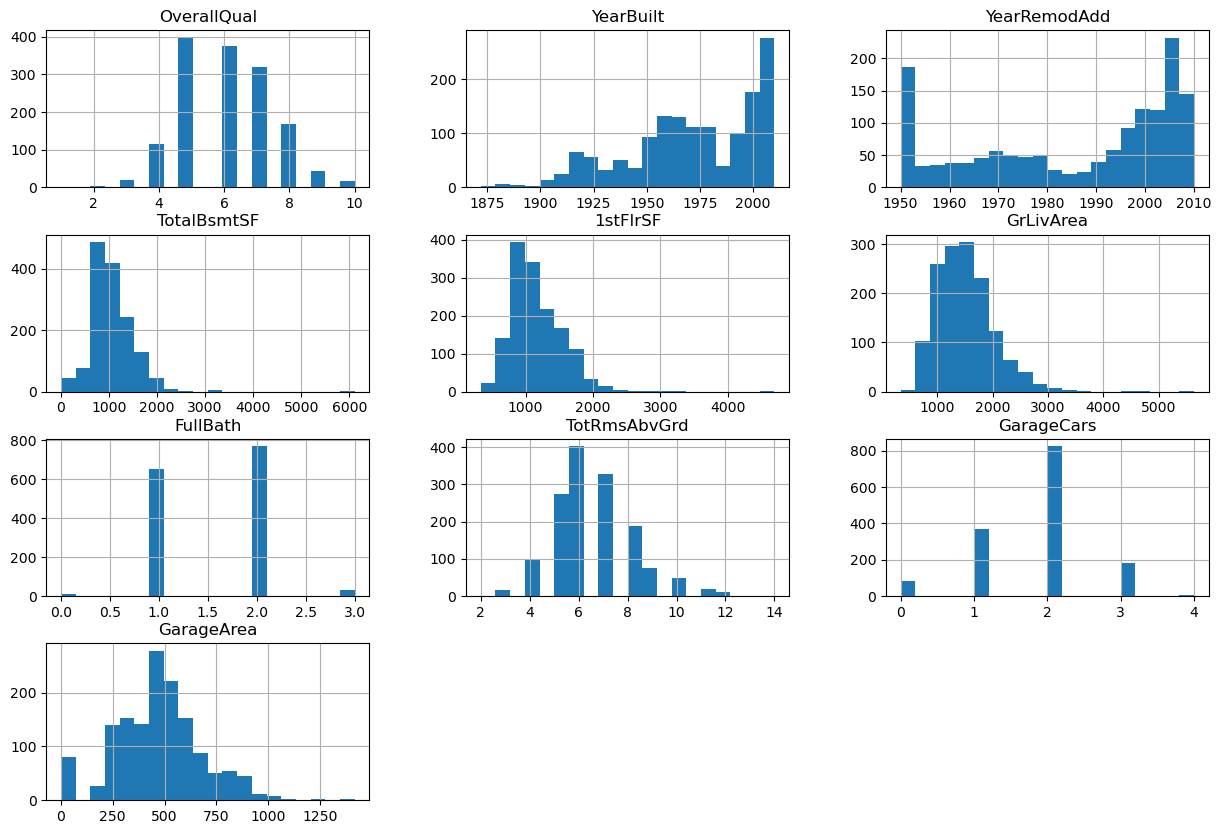

In [233]:
all_data.iloc[:1460][numeric].hist(bins=20, figsize=(15, 10))

Видим, что у нас есть выбросы в TotalBsmtSF, 1stFlrSF, GrLivArea. Можно также более детально рассмотреть GarageArea.

<Axes: >

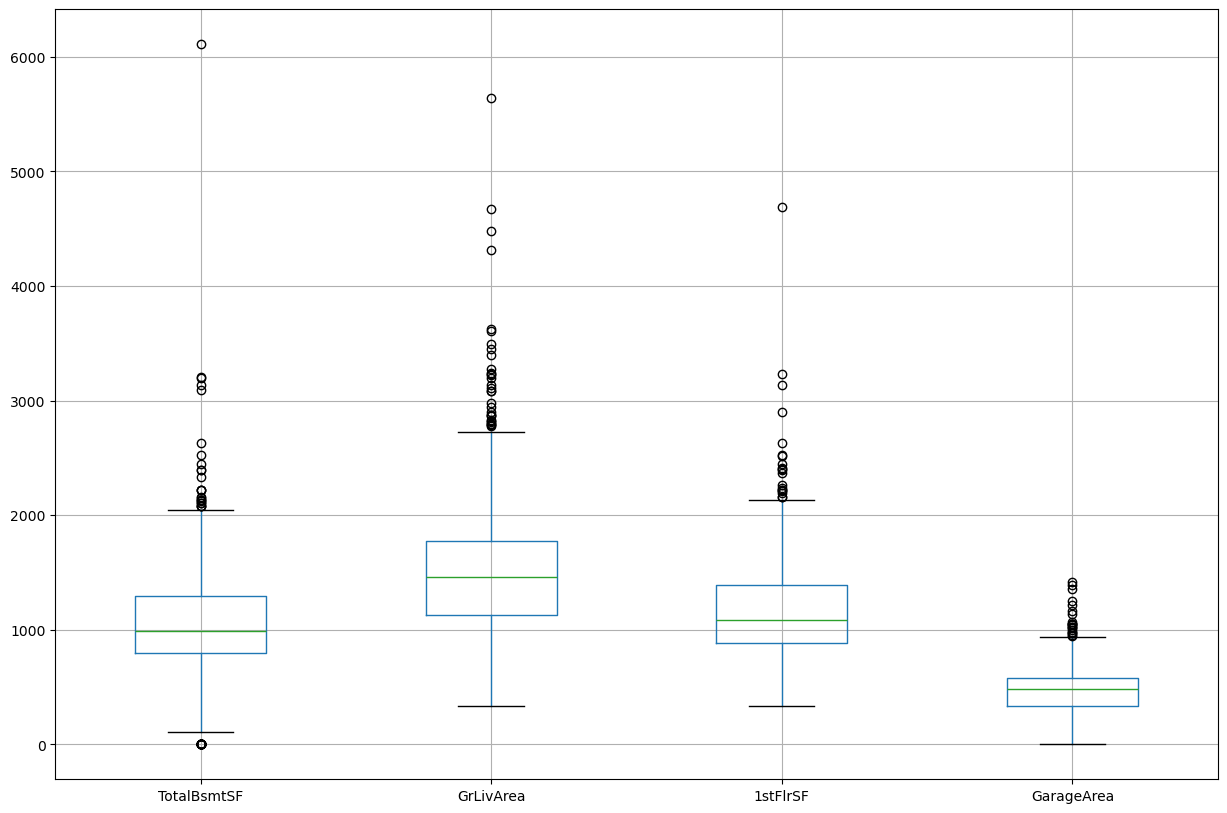

In [234]:
all_data.iloc[:1460][['TotalBsmtSF', 'GrLivArea', '1stFlrSF', 'GarageArea']].boxplot(figsize=(15, 10))

Посмотрим на все выбросы внимательнее. 

Найдено аномалий: 11


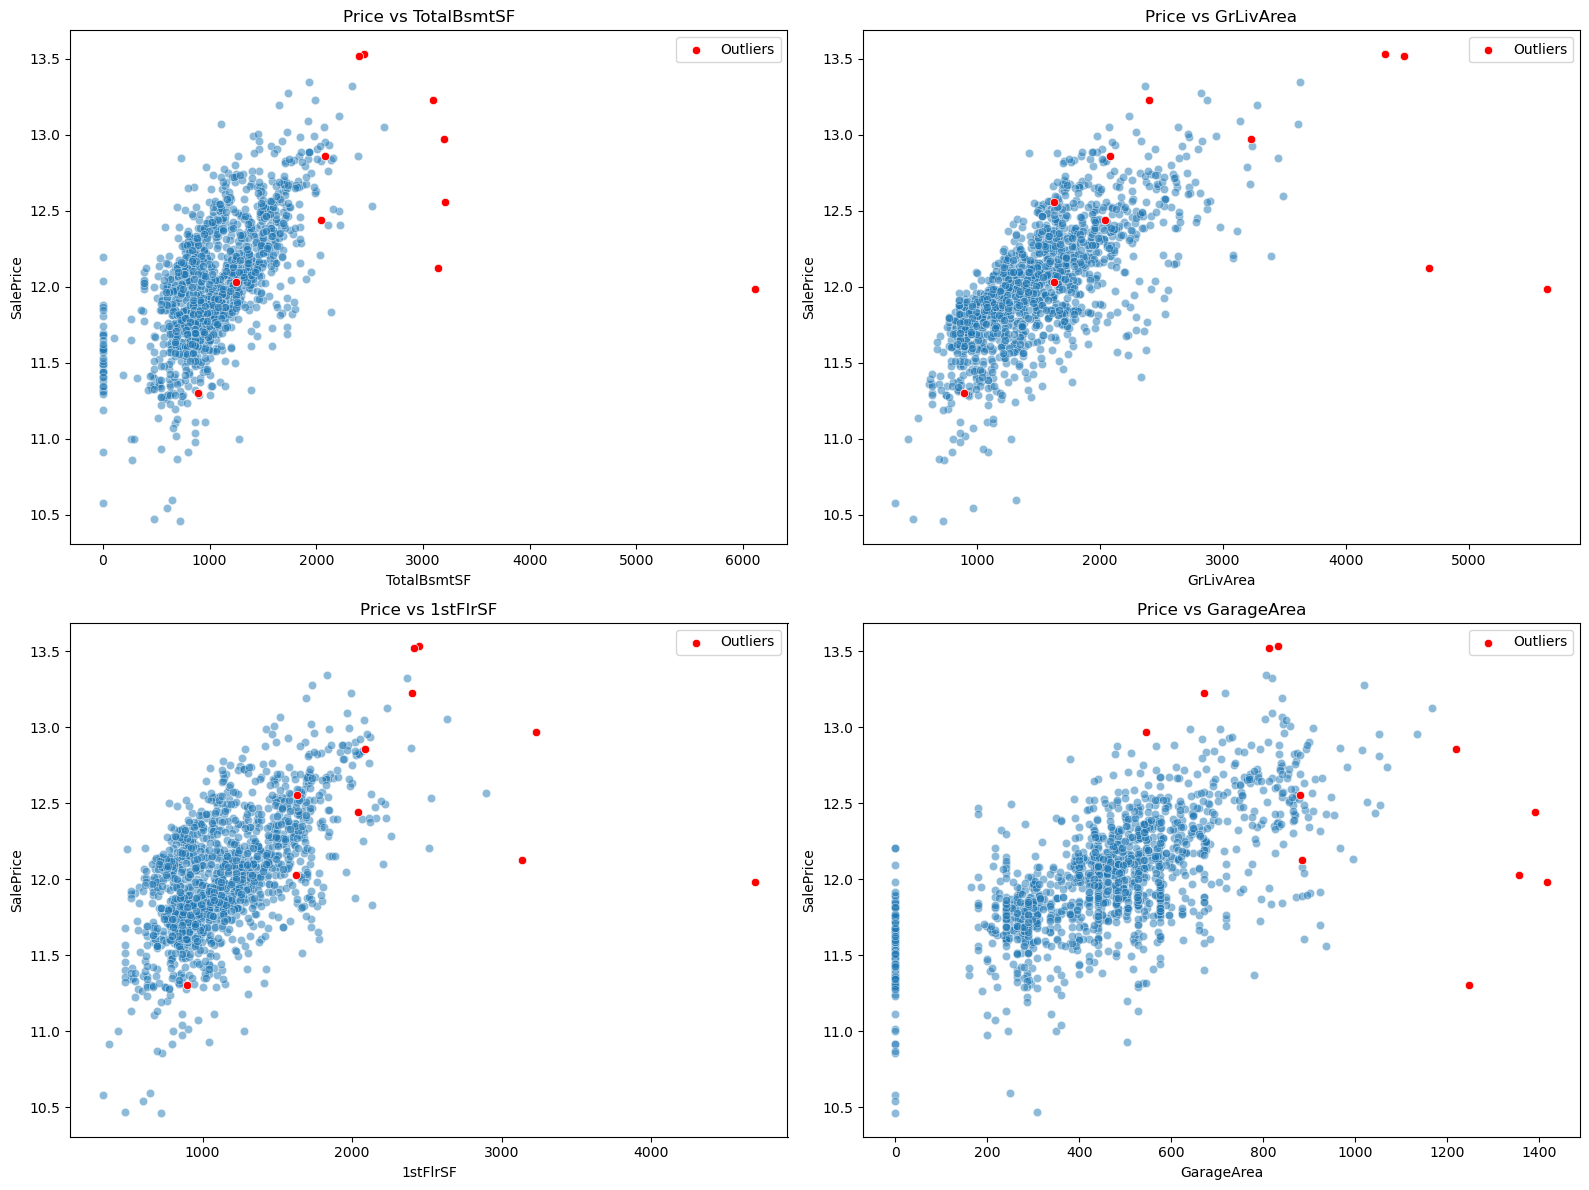

In [235]:
# 1. Сначала выделяем только тренировочную часть из all_data
train_part = all_data.iloc[:1460].copy()
train_part['SalePrice'] = y.values # Добавляем таргет для наглядности

# 2. Формируем маску аномалий
outliers_mask = (
    (train_part['TotalBsmtSF'] > 3000) | 
    (train_part['GrLivArea'] > 4000) | 
    (train_part['1stFlrSF'] > 3000) | 
    (train_part['GarageArea'] > 1200)
)

# 3. Смотрим на найденные аномалии
outliers = train_part[outliers_mask]
print(f"Найдено аномалий: {len(outliers)}")

features_to_check = ['TotalBsmtSF', 'GrLivArea', '1stFlrSF', 'GarageArea']

# Создаем сетку графиков 2x2
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten() # "Разглаживаем" матрицу осей в плоский список для удобства итерации

for i, col in enumerate(features_to_check):
    # Рисуем все точки (синим)
    sns.scatterplot(data=train_part, x=col, y='SalePrice', ax=axes[i], alpha=0.5)
    
    # Выделяем аномалии (красным), если они попадают под наши условия
    # (Здесь мы берем те же условия, что были в маске outliers_mask)
    current_outliers = outliers[outliers[col] > 0] # Показываем только те, что имеют значение в этом признаке
    sns.scatterplot(data=outliers, x=col, y='SalePrice', ax=axes[i], color='red', label='Outliers')
    
    axes[i].set_title(f'Price vs {col}')
    axes[i].legend()

plt.tight_layout() # Чтобы графики не накладывались друг на друга
plt.show()

In [236]:

indices_to_drop = outliers.index
train_part = train_part.drop(indices_to_drop, axis=0)

# таргет тоже нужно обновить, чтобы размеры совпадали
y = train_part['SalePrice']

all_data = pd.concat([train_part.drop('SalePrice', axis=1), all_data.iloc[1460:]], ignore_index=True)

# 6. Углубленный Feature Engeneering

In [237]:
# Общая площадь дома
all_data['TotalSF'] = all_data['TotalBsmtSF'] + all_data['1stFlrSF'] + all_data['2ndFlrSF']

# Общая площадь веранд
all_data['TotalPorchSF'] = (all_data['OpenPorchSF'] + all_data['EnclosedPorch'] + 
                            all_data['3SsnPorch'] + all_data['ScreenPorch'] + 
                            all_data['WoodDeckSF'])

In [238]:
# Возраст дома на момент продажи
all_data['HouseAge'] = all_data['YrSold'] - all_data['YearBuilt']

# Лет с момента реновации
all_data['TimeSinceRemod'] = all_data['YrSold'] - all_data['YearRemodAdd']


Давайте сделаем отдельные признаки про наличие второго этажа, подвала, гаража, камина и бассейна

In [239]:
all_data['Has2ndFloor'] = (all_data['2ndFlrSF'] > 0).astype(int)
all_data['HasGarage'] = (all_data['GarageArea'] > 0).astype(int)
all_data['HasBasement'] = (all_data['TotalBsmtSF'] > 0).astype(int)
all_data['HasFireplace'] = (all_data['Fireplaces'] > 0).astype(int)
all_data['HasPool'] = (all_data['PoolArea'] > 0).astype(int)

Обновим теперь списки используемых признаков.

In [240]:
numeric = [
    'OverallQual', 
    'HouseAge',        # Заменили YearBuilt
    'TimeSinceRemod',   # Заменили YearRemodAdd    
    'GrLivArea',      
    'TotalBsmtSF',     
    '1stFlrSF',        
    'TotRmsAbvGrd', 
    'GarageCars', 
    'GarageArea',
    'TotalSF',
    'TotalPorchSF',         
    'Has2ndFloor',     
    'HasGarage',       
    'HasBasement',     
    'HasFireplace',    
    'HasPool'
]

# 6. Вторая иттерация CatBoost с новыми признаками и удалением аномалий

In [241]:
X_catboost2 = all_data[numeric + categicorical].iloc[:1449]
y_catboost2 = y
X_catboost2_test = all_data[numeric + categicorical].iloc[1449:]

In [242]:
X_catboost2.shape, y_catboost2.shape, X_catboost2_test.shape    

((1449, 25), (1449,), (1459, 25))

In [243]:
# def objective(trial):
#     # 1. Задаем пространство поиска гиперпараметров
#     param = {
#         'iterations': trial.suggest_int('iterations', 500, 2000),
#         'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
#         'depth': trial.suggest_int('depth', 4, 10),
#         'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1, 10),
#         'min_data_in_leaf': trial.suggest_int('min_data_in_leaf', 1, 50),
#         'eval_metric': 'RMSE',
#         'random_seed': 42,
#         'od_type': 'Iter',
#         'od_wait': 50,
#         'verbose': False # Отключаем вывод, чтобы не засорять ноутбук
#     }

#     # 2. Настраиваем K-Fold
#     kf = KFold(n_splits=5, shuffle=True, random_state=42)
#     cv_scores = []
    
#     # 3. Цикл по фолдам
#     for train_idx, val_idx in kf.split(X_catboost2):
#         # Аккуратно разделяем данные через iloc
#         X_tr, y_tr = X_catboost2.iloc[train_idx], y_catboost2.iloc[train_idx]
#         X_va, y_va = X_catboost2.iloc[val_idx], y_catboost2.iloc[val_idx]
        
#         # Создаем пулы
#         train_pool = Pool(X_tr, y_tr, cat_features=categicorical)
#         val_pool = Pool(X_va, y_va, cat_features=categicorical)
        
#         # Обучаем модель
#         model = CatBoostRegressor(**param)
#         model.fit(train_pool, eval_set=val_pool)
        
#         # Предсказываем и считаем метрику для текущего фолда
#         preds = model.predict(val_pool)
#         rmse = root_mean_squared_error(y_va, preds)
#         cv_scores.append(rmse)
        
#     # 4. Возвращаем среднее значение RMSE по всем 5 фолдам
#     return np.mean(cv_scores)

In [244]:
# # Создаем объект исследования (ищем минимум ошибки)
# study = optuna.create_study(direction='minimize')

# # Запускаем оптимизацию (n_trials = кол-во попыток)
# print("Начинаем поиск лучших параметров...")
# study.optimize(objective, n_trials=30, show_progress_bar=True)

# print(f"\\nЛучший средний RMSE: {study.best_value:.5f}")
# print("Лучшие параметры:")
# for key, value in study.best_params.items():
#     print(f"    {key}: {value}")

In [245]:
# # --- СОХРАНЕНИЕ ПАРАМЕТРОВ ---
# # Если раскомментируешь и запустишь Optuna, раскомментируй и эти строки, 
# # чтобы сохранить результат:
# best_params = study.best_params
# with open('catboost_best_params_2.json', 'w') as f:
#     json.dump(best_params, f, indent=4)
# print("Параметры успешно сохранены в catboost_best_params_2.json!")

In [246]:
# params_filename = 'catboost_best_params_2.json'

# if os.path.exists(params_filename):
#     print(f"✅ Файл {params_filename} найден. Загружаем параметры...")
#     with open(params_filename, 'r') as f:
#         best_params = json.load(f)
# else:
#     print(f"⚠️ Файл {params_filename} не найден!")

# best_params['eval_metric'] = 'RMSE'
# best_params['random_seed'] = 42
# best_params['verbose'] = 200

# kf = KFold(n_splits=5, shuffle=True, random_state=42)

# # Массив для хранения предсказаний для теста (будем их суммировать)
# test_predictions = np.zeros(len(X_catboost2_test))
# oof_rmse_scores = []

# for fold, (train_idx, val_idx) in enumerate(kf.split(X_catboost2)):
#     print(f"\\n--- Обучение фолда {fold + 1} ---")
    
#     X_tr, y_tr = X_catboost2.iloc[train_idx], y_catboost2.iloc[train_idx]
#     X_va, y_va = X_catboost2.iloc[val_idx], y_catboost2.iloc[val_idx]
    
#     train_pool = Pool(X_tr, y_tr, cat_features=categicorical)
#     val_pool = Pool(X_va, y_va, cat_features=categicorical)
#     test_pool = Pool(X_catboost2_test, cat_features=categicorical)
    
#     # Модель с ЛУЧШИМИ параметрами от Optuna
#     model = CatBoostRegressor(**best_params)
#     model.fit(train_pool, eval_set=val_pool)
    
#     # Считаем скор на валидации фолда
#     fold_preds = model.predict(val_pool)
#     fold_rmse = root_mean_squared_error(y_va, fold_preds)
#     oof_rmse_scores.append(fold_rmse)
    
#     # ПРЕДСКАЗАНИЕ НА TEST: делим на количество фолдов, чтобы получить среднее
#     test_predictions += model.predict(test_pool) / kf.n_splits

# print(f"\\nСредний RMSE по фолдам: {np.mean(oof_rmse_scores):.5f}")

# # Создаем сабмит
# submission = pd.DataFrame({
#     "Id": test_id,
#     "SalePrice": np.expm1(test_predictions) # Возвращаем из логарифма
# })
# submission.to_csv("submission_catboost_optuna_cv_2.csv", index=False)
# print("Файл submission_catboost_optuna_cv_2.csv успешно сохранен!")

# 7. One-Hot и StandardScaler

In [251]:
# Создаем трансформер колонок
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categicorical)
    ])

# Применяем к нашим данным (возвращает numpy массивы)
X_processed = preprocessor.fit_transform(X_catboost2.reset_index(drop=True))
X_test_processed = preprocessor.transform(X_catboost2_test.reset_index(drop=True))

y_train = y_catboost2.values

In [252]:
def objective_lgbm(trial):
    param = {
        'n_estimators': trial.suggest_int('n_estimators', 500, 2000),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'num_leaves': trial.suggest_int('num_leaves', 15, 100),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 50),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'random_state': 42,
        'verbose': -1,
        'n_jobs': -1
    }

    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    cv_scores = []
    
    for train_idx, val_idx in kf.split(X_processed):
        # Обрати внимание: X_processed - это numpy array, поэтому обращаемся без .iloc
        X_tr, y_tr = X_processed[train_idx], y_train[train_idx]
        X_va, y_va = X_processed[val_idx], y_train[val_idx]
        
        model = LGBMRegressor(**param)
        
        # В новых версиях LightGBM early_stopping передается через callbacks
        from lightgbm import early_stopping
        model.fit(
            X_tr, y_tr,
            eval_set=[(X_va, y_va)],
            callbacks=[early_stopping(stopping_rounds=50, verbose=False)]
        )
        
        preds = model.predict(X_va)
        rmse = root_mean_squared_error(y_va, preds)
        cv_scores.append(rmse)
        
    return np.mean(cv_scores)

print("Начинаем поиск лучших параметров для LightGBM...")
study_lgbm = optuna.create_study(direction='minimize')
study_lgbm.optimize(objective_lgbm, n_trials=30, show_progress_bar=True)

print(f"\nЛучший средний RMSE LightGBM: {study_lgbm.best_value:.5f}")

[I 2026-04-06 17:32:37,366] A new study created in memory with name: no-name-d0f7b126-1bd4-4062-a50f-205e7cbc304a


Начинаем поиск лучших параметров для LightGBM...


  0%|          | 0/30 [00:00<?, ?it/s]

c:\Users\Shurik\anaconda3\envs\ml_1\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\Shurik\anaconda3\envs\ml_1\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\Shurik\anaconda3\envs\ml_1\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\Shurik\anaconda3\envs\ml_1\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\Shurik\anaconda3\envs\ml_1\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  

[I 2026-04-06 17:32:38,232] Trial 0 finished with value: 0.13972264928466063 and parameters: {'n_estimators': 987, 'learning_rate': 0.012837113349905505, 'max_depth': 5, 'num_leaves': 16, 'min_child_samples': 48, 'subsample': 0.9218944914469726, 'colsample_bytree': 0.69000322129165}. Best is trial 0 with value: 0.13972264928466063.


...

[I 2026-04-06 17:32:52,670] Trial 27 finished with value: 0.13376430098092804 and parameters: {'n_estimators': 1853, 'learning_rate': 0.05513902954925763, 'max_depth': 3, 'num_leaves': 46, 'min_child_samples': 13, 'subsample': 0.8483229752616059, 'colsample_bytree': 0.7762645163745757}. Best is trial 21 with value: 0.13089661644997355.


c:\Users\Shurik\anaconda3\envs\ml_1\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\Shurik\anaconda3\envs\ml_1\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\Shurik\anaconda3\envs\ml_1\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[I 2026-04-06 17:32:52,892] Trial 28 finished with value: 0.13648340076083962 and parameters: {'n_estimators': 1246, 'learning_rate': 0.0810633155523019, 'max_depth': 4, 'num_leaves': 34, 'min_child_samples': 24, 'subsample': 0.7554840576258156, 'colsample_bytree': 0.7115049996107983}. Best is trial 21 with value: 0.13089661644997355.


c:\Users\Shurik\anaconda3\envs\ml_1\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\Shurik\anaconda3\envs\ml_1\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\Shurik\anaconda3\envs\ml_1\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[I 2026-04-06 17:32:53,300] Trial 29 finished with value: 0.1386139611356 and parameters: {'n_estimators': 919, 'learning_rate': 0.04245255205350863, 'max_depth': 5, 'num_leaves': 56, 'min_child_samples': 43, 'subsample': 0.7065871294361193, 'colsample_bytree': 0.6846162644982675}. Best is trial 21 with value: 0.13089661644997355.

Лучший средний RMSE LightGBM: 0.13090


In [254]:
def objective_xgb(trial):
    param = {
        'n_estimators': trial.suggest_int('n_estimators', 500, 2000),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'random_state': 42,
        'n_jobs': -1,
        'eval_metric': 'rmse',
        'early_stopping_rounds': 50
    }

    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    cv_scores = []
    
    for train_idx, val_idx in kf.split(X_processed):
        X_tr, y_tr = X_processed[train_idx], y_train[train_idx]
        X_va, y_va = X_processed[val_idx], y_train[val_idx]
        
        model = XGBRegressor(**param)
        
        model.fit(
            X_tr, y_tr,
            eval_set=[(X_va, y_va)],
            verbose=False
        )
        
        preds = model.predict(X_va)
        rmse = root_mean_squared_error(y_va, preds)
        cv_scores.append(rmse)
        
    return np.mean(cv_scores)

print("Начинаем поиск лучших параметров для XGBoost...")
study_xgb = optuna.create_study(direction='minimize')
study_xgb.optimize(objective_xgb, n_trials=30, show_progress_bar=True)

print(f"\nЛучший средний RMSE XGBoost: {study_xgb.best_value:.5f}")

[I 2026-04-06 17:34:12,422] A new study created in memory with name: no-name-37c10bda-f3b2-4f0e-ad5a-9e4ab2faa3d1


Начинаем поиск лучших параметров для XGBoost...


  0%|          | 0/30 [00:00<?, ?it/s]

[I 2026-04-06 17:34:13,050] Trial 0 finished with value: 0.1316927330668698 and parameters: {'n_estimators': 755, 'learning_rate': 0.06931657494079542, 'max_depth': 3, 'min_child_weight': 8, 'subsample': 0.8337910232528916, 'colsample_bytree': 0.7050290028037771}. Best is trial 0 with value: 0.1316927330668698.
[I 2026-04-06 17:34:13,838] Trial 1 finished with value: 0.13938584865142284 and parameters: {'n_estimators': 1066, 'learning_rate': 0.07475591920701294, 'max_depth': 9, 'min_child_weight': 1, 'subsample': 0.6809386375787674, 'colsample_bytree': 0.6039238585743419}. Best is trial 0 with value: 0.1316927330668698.
[I 2026-04-06 17:34:15,346] Trial 2 finished with value: 0.13236024034213528 and parameters: {'n_estimators': 1230, 'learning_rate': 0.01940564914099482, 'max_depth': 4, 'min_child_weight': 3, 'subsample': 0.9686030730774486, 'colsample_bytree': 0.6122007032387223}. Best is trial 0 with value: 0.1316927330668698.
[I 2026-04-06 17:34:15,915] Trial 3 finished with value: 

In [255]:
best_xgb_params = study_xgb.best_params
best_xgb_params['random_state'] = 42
best_xgb_params['n_jobs'] = -1
best_xgb_params['eval_metric'] = 'rmse'
best_xgb_params['early_stopping_rounds'] = 50

kf = KFold(n_splits=5, shuffle=True, random_state=42)
xgb_test_predictions = np.zeros(len(X_test_processed))
oof_rmse_scores = []

for fold, (train_idx, val_idx) in enumerate(kf.split(X_processed)):
    print(f"\n--- Обучение фолда {fold + 1} (XGBoost) ---")
    
    X_tr, y_tr = X_processed[train_idx], y_train[train_idx]
    X_va, y_va = X_processed[val_idx], y_train[val_idx]
    
    model = XGBRegressor(**best_xgb_params)
    model.fit(
        X_tr, y_tr,
        eval_set=[(X_va, y_va)],
        verbose=100
    )
    
    fold_preds = model.predict(X_va)
    fold_rmse = root_mean_squared_error(y_va, fold_preds)
    oof_rmse_scores.append(fold_rmse)
    
    xgb_test_predictions += model.predict(X_test_processed) / kf.n_splits

print(f"\nСредний RMSE XGBoost по фолдам: {np.mean(oof_rmse_scores):.5f}")

submission_xgb = pd.DataFrame({
    "Id": test_id,
    "SalePrice": np.expm1(xgb_test_predictions)
})
submission_xgb.to_csv("submission_xgboost_optuna_cv.csv", index=False)
print("Файл submission_xgboost_optuna_cv.csv успешно сохранен!")


--- Обучение фолда 1 (XGBoost) ---
[0]	validation_0-rmse:0.35595
[100]	validation_0-rmse:0.13233
[200]	validation_0-rmse:0.13029
[243]	validation_0-rmse:0.13085

--- Обучение фолда 2 (XGBoost) ---
[0]	validation_0-rmse:0.40219
[100]	validation_0-rmse:0.14166
[200]	validation_0-rmse:0.13767
[300]	validation_0-rmse:0.13658
[313]	validation_0-rmse:0.13650

--- Обучение фолда 3 (XGBoost) ---
[0]	validation_0-rmse:0.36232
[100]	validation_0-rmse:0.13272
[200]	validation_0-rmse:0.12841
[300]	validation_0-rmse:0.12790
[370]	validation_0-rmse:0.12793

--- Обучение фолда 4 (XGBoost) ---
[0]	validation_0-rmse:0.38194
[100]	validation_0-rmse:0.12746
[200]	validation_0-rmse:0.12363
[291]	validation_0-rmse:0.12331

--- Обучение фолда 5 (XGBoost) ---
[0]	validation_0-rmse:0.38470
[100]	validation_0-rmse:0.14056
[200]	validation_0-rmse:0.13563
[300]	validation_0-rmse:0.13291
[400]	validation_0-rmse:0.13198
[500]	validation_0-rmse:0.13111
[600]	validation_0-rmse:0.13062
[676]	validation_0-rmse:0.1306

In [257]:
best_lgbm_params = study_lgbm.best_params
best_lgbm_params['random_state'] = 42
best_lgbm_params['n_jobs'] = -1
best_lgbm_params['eval_metric'] = 'rmse'
best_lgbm_params['early_stopping_rounds'] = 50

kf = KFold(n_splits=5, shuffle=True, random_state=42)
lgbm_test_predictions = np.zeros(len(X_test_processed))
oof_rmse_scores = []

for fold, (train_idx, val_idx) in enumerate(kf.split(X_processed)):
    print(f"\n--- Обучение фолда {fold + 1} (LightGBM) ---")
    
    X_tr, y_tr = X_processed[train_idx], y_train[train_idx]
    X_va, y_va = X_processed[val_idx], y_train[val_idx]
    
    model = LGBMRegressor(**best_lgbm_params)
    model.fit(
        X_tr, y_tr,
        eval_set=[(X_va, y_va)],
    )
    
    fold_preds = model.predict(X_va)
    fold_rmse = root_mean_squared_error(y_va, fold_preds)
    oof_rmse_scores.append(fold_rmse)
    
    lgbm_test_predictions += model.predict(X_test_processed) / kf.n_splits

print(f"\nСредний RMSE LightGBM по фолдам: {np.mean(oof_rmse_scores):.5f}")

submission_lgbm = pd.DataFrame({
    "Id": test_id,
    "SalePrice": np.expm1(lgbm_test_predictions)
})
submission_lgbm.to_csv("submission_lightgbm_optuna_cv.csv", index=False)
print("Файл submission_lightgbm_optuna_cv.csv успешно сохранен!")


--- Обучение фолда 1 (LightGBM) ---
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[308]	valid_0's l2: 0.0181979

--- Обучение фолда 2 (LightGBM) ---
Training until validation scores don't improve for 50 rounds


c:\Users\Shurik\anaconda3\envs\ml_1\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\Shurik\anaconda3\envs\ml_1\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\Shurik\anaconda3\envs\ml_1\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\Shurik\anaconda3\envs\ml_1\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\Shurik\anaconda3\envs\ml_1\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  

Early stopping, best iteration is:
[323]	valid_0's l2: 0.0188863

--- Обучение фолда 3 (LightGBM) ---
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[281]	valid_0's l2: 0.0171981

--- Обучение фолда 4 (LightGBM) ---
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[579]	valid_0's l2: 0.0149124

--- Обучение фолда 5 (LightGBM) ---
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[742]	valid_0's l2: 0.0166148

Средний RMSE LightGBM по фолдам: 0.13090
Файл submission_lightgbm_optuna_cv.csv успешно сохранен!


c:\Users\Shurik\anaconda3\envs\ml_1\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\Shurik\anaconda3\envs\ml_1\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\Shurik\anaconda3\envs\ml_1\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\Shurik\anaconda3\envs\ml_1\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
